# Ximenez: Parse

In [375]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
# pd.set_option('display.max_colwidth', False)

In [376]:
src_id = 'ximenez'

# Source to ana_list and data

In [377]:
xml_lines = open("xom-all-flat-mod-pnums.xml").readlines()

In [378]:
els = dict(
    lang = '',
    folio = 0,
    side = 0,
    para_num = 0,
    lb = 0,
    # lb_n  = '' # Line number as given
)

data = []
ana_list = []

for line in xml_lines:
    
    # Grab column (lang) 
    # Pattern: <div xml:lang="quc" type="column" rend="left half">
    if re.match(r"<div xml:lang", line):
        els['lang'] = line.split('"')[1].split('"')[0]
        els['para_num'] = 0

    # Grab manuscript
    if re.match(r"^<pb ", line):
        f, s = line.split("xom-")[1].split('"')[0].split('-')
        els['folio'] = int(f[1:])
        els['side'] = int(s[1:])
        els['lb'] = 0

    # Grab paragraph
    if re.match(r"^<p ", line):
        els['para_num'] += 1

    # Grab line break
    if re.match(r"^<lb n=", line):
        # els['lb_n'] = line.split('<lb n="')[1].split('"')[0]
        els['lb'] += 1
        els['lb_str'] = ' '.join(line.split("/>")[1:]).strip()
        
        # Grab RS elements
        ana_num = 0
        rs = line.split("<rs ")
        if len(rs) > 1:
            for r in rs[1:]:
                ana = r.split('"')[1]  
                ana_num += 1
                # ana_list.append((els['lang'], els['folio'], els['side'], els['para_num'], els['lb'], els['lb_n'], ana_num, ana))
                ana_list.append((els['lang'], els['folio'], els['side'], els['para_num'], els['lb'], ana_num, ana))

        data.append(tuple(els.values()))

# data to LINE

In [379]:
LINE = pd.DataFrame(data, columns=els.keys())
LINE = LINE.set_index(['lang', 'folio', 'side', 'para_num', 'lb'])
assert LINE.index.has_duplicates == False, "LINE has duplicates"
LINE

lb_str
lang folio side para_num lb                                                   
quc  1     1    1        1            <hi rend="very-large">ARE V XE OHER</hi>
                         2                               Ꜩih varal Quiche vbi.
                2        3   <hi rend="large">V</hi>aral xchicaꜩibah vi xch...
                         4                    tiquiba vi oher ꜩih, vticaribal,
                         5                         vxenabal puch ronohel xban,
...                                                                        ...
spa  56    2    100      31  quiche</rs>. <choice><abbr>porq’</abbr><expan ...
                         32  yaun<choice><abbr>q’</abbr><expan instant="fal...
                         33   se ha perdído. y aquí seacabo todo lo<pc> –</pc>
                         34  tocante <rs ana="TINAMIT_K'ICHE'">al quiche</r...
                         35                                         Cruz.</rs>

[10177 rows x 1 columns]

**Clean line strings**

In [380]:
LINE['lb_str_plain'] = (
    LINE.lb_str
    .str.replace(r"<[^>]+/?>", "", regex=True)
    .str.replace(" –", "–", regex=False)
)
chars = {
    'Ꜩ': 'Tz',
    'ꜩ': 'tz',
    'ꜫ': "q'",
    'ÿ': 'i', # actually 'ij' 
}
for char in chars:
    LINE.lb_str_plain = LINE.lb_str_plain.str.replace(char, chars[char], regex=False)
LINE

lb_str  \
lang folio side para_num lb                                                      
quc  1     1    1        1            <hi rend="very-large">ARE V XE OHER</hi>   
                         2                               Ꜩih varal Quiche vbi.   
                2        3   <hi rend="large">V</hi>aral xchicaꜩibah vi xch...   
                         4                    tiquiba vi oher ꜩih, vticaribal,   
                         5                         vxenabal puch ronohel xban,   
...                                                                        ...   
spa  56    2    100      31  quiche</rs>. <choice><abbr>porq’</abbr><expan ...   
                         32  yaun<choice><abbr>q’</abbr><expan instant="fal...   
                         33   se ha perdído. y aquí seacabo todo lo<pc> –</pc>   
                         34  tocante <rs ana="TINAMIT_K'ICHE'">al quiche</r...   
                         35                                         Cruz.</rs>   

                                                           lb_str_plain  
lang folio side para_num lb                                              
quc  1     1    1        1                                ARE V XE OHER  
                         2                       Tzih varal Quiche vbi.  
                2        3                Varal xchicatzibah vi xchica–  
                         4            tiquiba vi oher tzih, vticaribal,  
                         5                  vxenabal puch ronohel xban,  
...                                                                 ...  
spa  56    2    100      31   quiche. porq’porque ya no ay donde leerlo  
                         32        yaunq’que antíguamente lo auía, pero  
                         33      se ha perdído. y aquí seacabo todo lo–  
                         34  tocante al quiche, q’que se llama StaSanta  
                         35                                       Cruz.  

[10177 rows x 2 columns]

# LINE to DOC

In [381]:
LINE_QUC = LINE.loc['quc']
DOC = LINE_QUC.groupby(['para_num']).lb_str_plain\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame('doc_str')
DOC.doc_str = DOC.doc_str.str.replace(r"– ", "").str.strip()
DOC

,doc_str
para_num,
1,ARE V XE OHER Tzih varal Quiche vbi.
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...
3,"ARE V TzIHOXIC VAE Cacatzinin oc, caca chamam ..."
4,Vae cute nabe tzih nabe vchan. mahabi oq' hun ...
5,Ta xpe cut vtzih varal xul cuq ri tepeu gucuma...
...,...
93,Arecut nim ha ri chuvach nihaibab are vbinaam ...
94,Are chicut rech ahau qui che va vmam vcahau Ma...
95,Arecut ahauab ri chuvach ahau quiche are vleel...


# DOC to TOKEN

In [382]:
TOKEN = DOC.doc_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = DOC.index.names + ['token_num']
TOKEN['term_str'] = TOKEN.token_str.str.lower().str.replace(r"[^a-z']", "", regex=True)
TOKEN

token_str    term_str
para_num token_num                        
1        0                 ARE         are
         1                   V           v
         2                  XE          xe
         3                OHER        oher
         4                Tzih        tzih
...                        ...         ...
97       39         chiconohel  chiconohel
         40             quiche      quiche
         41          Sta.Santa    stasanta
         42               Cruz        cruz
         43               vbi.         vbi

[25931 rows x 2 columns]

# TOKEN to VOCAB 

In [383]:
VOCAB = TOKEN.term_str.value_counts().to_frame('n').sort_index()
VOCAB = VOCAB[VOCAB.index != ""].copy()
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB

,n,p,i,h
term_str,,,,
a,53,0.002044,8.934136,0.018265
ab,1,0.000039,14.662056,0.000566
abah,24,0.000926,10.077094,0.009329
abanel,1,0.000039,14.662056,0.000566
abanoh,1,0.000039,14.662056,0.000566
...,...,...,...,...
zui,1,0.000039,14.662056,0.000566
zul,1,0.000039,14.662056,0.000566
zutz,1,0.000039,14.662056,0.000566


# TOKEN to CHUNK

In [384]:
n_chunks = 60

TOKEN['chunk_num'] = pd.cut(TOKEN.reset_index().index, n_chunks, labels=[x for x in range(n_chunks)])
TOKEN

token_str    term_str chunk_num
para_num token_num                                  
1        0                 ARE         are         0
         1                   V           v         0
         2                  XE          xe         0
         3                OHER        oher         0
         4                Tzih        tzih         0
...                        ...         ...       ...
97       39         chiconohel  chiconohel        59
         40             quiche      quiche        59
         41          Sta.Santa    stasanta        59
         42               Cruz        cruz        59
         43               vbi.         vbi        59

[25931 rows x 3 columns]

In [385]:
CHUNK = TOKEN.groupby('chunk_num', observed=True).term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK.head()

,chunk_str
chunk_num,
0,are v xe oher tzih varal quiche vbi varal xchi...
1,qazlem hupacha ta cha uaxoc ta caquiro puch ap...
2,xeqhauic xeqha chic qui bil quib maui mixutzin...
3,camul alom camul qaholom nimac nima tziz ah cu...
4,vach rumal che abah xqhauic ronohel qui quebal...


Add associated paragraph numbers to chapters.

In [386]:
CHUNK['doc_id'] = (
    TOKEN
    .join(CHUNK, on='chunk_num')
    .reset_index()
    .value_counts(['chunk_num', 'para_num'])
    .sort_index()
    .reset_index()
    .groupby('chunk_num', observed=True)
    .para_num.apply(lambda x: " ".join(map(str, x)))
)
CHUNK

,chunk_str,doc_id
chunk_num,,
0,are v xe oher tzih varal quiche vbi varal xchi...,1 2 3 4 5
1,qazlem hupacha ta cha uaxoc ta caquiro puch ap...,5 6 7
2,xeqhauic xeqha chic qui bil quib maui mixutzin...,7 8
3,camul alom camul qaholom nimac nima tziz ah cu...,8 9
4,vach rumal che abah xqhauic ronohel qui quebal...,9 10
5,rib rivxic vpuvac xere cut tocol vi v vach ri ...,10 11 12
6,xbe vqhapa cate cut ta xcupix vla veab rihun h...,12
7,vi nu caubal ri ve ruq vbac nu vach xchicacoh ...,12 13
8,hun nima hul naht xcahic ta xquitac cut ri zip...,13


# TOKEN to CTM

In [387]:
CTM = TOKEN.groupby(['chunk_num', 'term_str'], observed=True).term_str.count().unstack(fill_value=0)
CTM.head()

term_str,,a,ab,abah,abanel,abanoh,abi,abix,abixic,abixom,...,ztzah,zu,zuanic,zubac,zuculiquil,zui,zul,zutz,zutzil,zuy
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Choose SIGS

In [388]:
DP = CTM / CTM.sum()
DI = np.log2(1/DP).replace(np.inf, 0)
DH = DP * DI
VOCAB['dh'] = DH.sum()
VOCAB

,n,p,i,h,dh
term_str,,,,,
a,53,0.002044,8.934136,0.018265,4.901988
ab,1,0.000039,14.662056,0.000566,0.000000
abah,24,0.000926,10.077094,0.009329,3.907268
abanel,1,0.000039,14.662056,0.000566,0.000000
abanoh,1,0.000039,14.662056,0.000566,0.000000
...,...,...,...,...,...
zui,1,0.000039,14.662056,0.000566,0.000000
zul,1,0.000039,14.662056,0.000566,0.000000
zutz,1,0.000039,14.662056,0.000566,0.000000


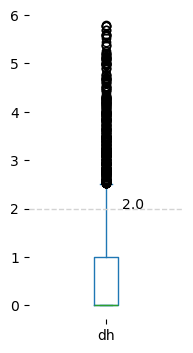

In [389]:
ax = VOCAB.dh.plot.box(figsize=(2,4))
vline = VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls='--', lw=1, c='lightgray')
ax.annotate(vline, xy=(1.1,2))
sns.despine(left=True, bottom=True)
plt.show()

In [390]:
dh_thresh = vline

sig_mask = VOCAB.dh > dh_thresh
SIGS = VOCAB[sig_mask].index
len(VOCAB), len(SIGS)

(5605, 518)

In [391]:
# This overrides the previous
SIGS = VOCAB.sort_values('dh').tail(500).index

# CTM to TFIDF

In [392]:
TF = CTM[SIGS]
DF = TF[TF > 0].sum()
IDF = np.log((n_chunks+1)/(DF+1)+1)
TFIDF = TF * IDF
L2_norm = np.sqrt((TFIDF**2).sum(1))
TFIDF_L2 = TFIDF.div(L2_norm, axis=0)

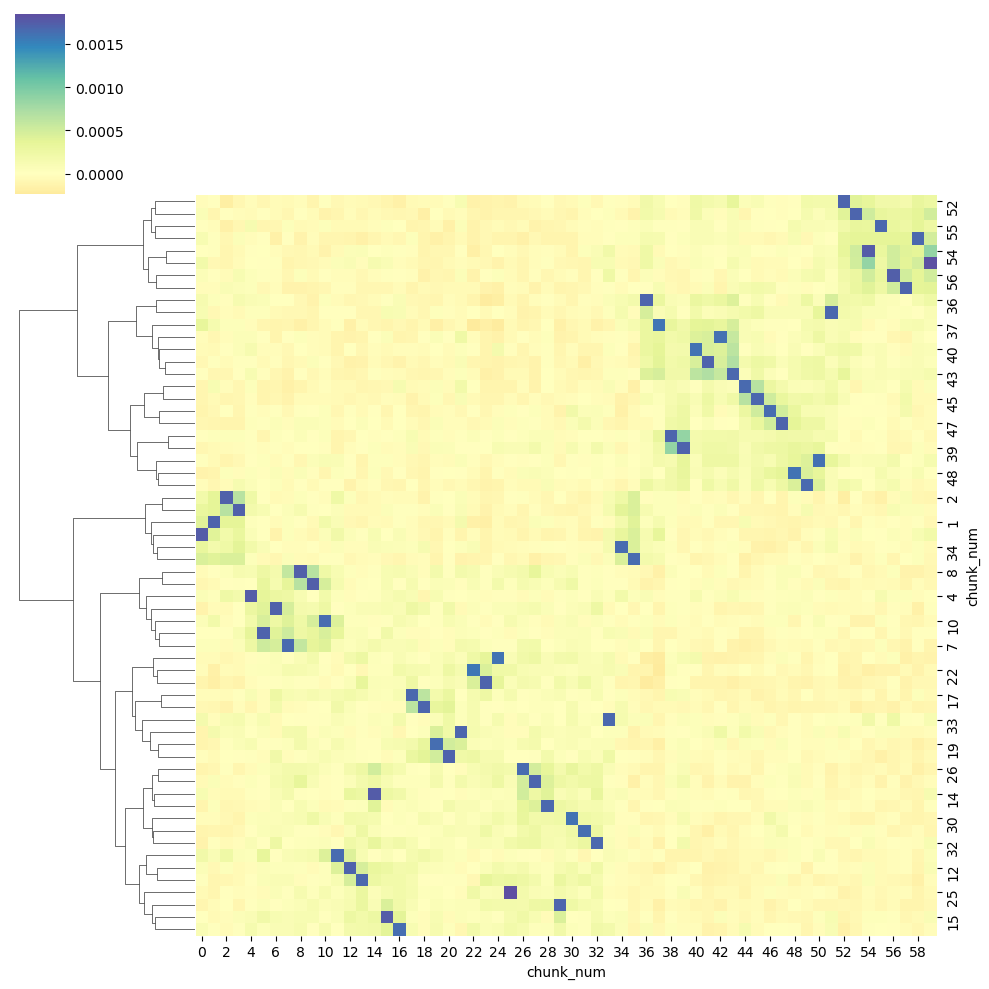

In [393]:
sns.clustermap(TFIDF_L2.T.cov(), cmap="Spectral", center=0, col_cluster=None, 
    metric='euclidean',
    method='ward')
plt.show()

# Save

In [394]:
TOKEN.to_csv(f"{src_id}-TOKEN.csv", index=True)
VOCAB.to_csv(f"{src_id}-VOCAB.csv", index=True)
LINE.to_csv(f"{src_id}-LINE.csv", index=True)
DOC.to_csv(f"{src_id}-DOC.csv", index=True)
CHUNK.to_csv(f"{src_id}-CHUNK-{n_chunks}.csv", index=True)
TFIDF_L2.to_csv(f"{src_id}-TFIDF-{n_chunks}.csv", index=True)

In [395]:
with open(f"{src_id}-DOC_idx.txt", "w") as out:
    out.write(",".join(DOC.index.names))

In [396]:
for lang in ['spa', 'quc']:
    LINE.loc[lang].to_csv(f"ximenez-{lang}-LINE.csv", index=True, sep='|')
    TEMA_TOKEN.loc[lang].to_csv(f"ximenez-{lang}-TEMA_TOKEN.csv", index=True, sep='|')
    
TEMA.to_csv(f"ximenez-{lang}-TEMA.csv", index=True, sep='|')

# Extra: View Temas

## ana_list to TEMA_TOKEN

In [397]:
ana_cols = list(els.keys())[:-1] + ['ana_num', 'ana_id']
TEMA_TOKEN = pd.DataFrame(ana_list, columns = ana_cols).set_index(ana_cols[:-1])
TEMA_TOKEN.sort_index()

ana_id
lang folio side para_num lb ana_num                 
quc  1     1    2        6  1        TINAMIT_K'ICHE'
                         10 1                TZ'AQOL
                            2                 B'ITOL
                         11 1                   ALOM
                            2               K'AJOLOM
...                                              ...
spa  56    2    100      29 1            NIM_CH'OKOJ
                         30 1        TINAMIT_K'ICHE'
                         31 1              POPOL_WUJ
                         34 1        TINAMIT_K'ICHE'
                            2             SANTA_CRUZ

[6109 rows x 1 columns]

## TEMA_TOKEN to TEMA

In [398]:
TEMA = TEMA_TOKEN.reset_index().value_counts(['lang','ana_id']).sort_index()\
    .to_frame('n').unstack(fill_value=0)
TEMA.columns = TEMA.columns.droplevel(0)
TEMA = TEMA.T 
TEMA['label'] = TEMA.apply(lambda x: x.name.replace('_', ' ').title(), axis=1)
TEMA

lang,quc,spa,label
ana_id,,,
AB'IX,18,17,Ab'Ix
ACHAQ'_IB'OY,1,1,Achaq' Ib'Oy
AJ,8,10,Aj
AJACHE',2,2,Ajache'
AJAL_MES,3,3,Ajal Mes
...,...,...,...
YAKI,5,4,Yaki
YAKI_TEPEW,1,1,Yaki Tepew
YAKOLATAM,1,1,Yakolatam


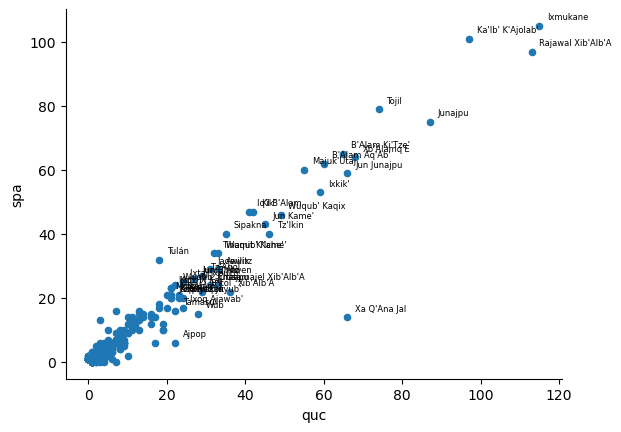

In [399]:
ax = TEMA.plot.scatter('quc', 'spa')
for i, row in TEMA[(TEMA.quc > 20) | (TEMA.spa > 20)].iterrows():
    ax.annotate(
        TEMA.loc[i].label, xy=(row['quc']+2, row['spa']+2), fontsize=6)
sns.despine()
plt.show()

## TEMA_TOKEN to TEMA_TOKEN_QUC

In [400]:
TEMA_TOKEN_QUC = TEMA_TOKEN.loc['quc']
TEMA_TOKEN_QUC

ana_id
folio side para_num lb ana_num                 
1     1    2        6  1        TINAMIT_K'ICHE'
                    10 1                TZ'AQOL
                       2                 B'ITOL
                    11 1                   ALOM
                       2               K'AJOLOM
...                                         ...
56    2    97       30 1            NIM_CH'OKOJ
                    32 1        TINAMIT_K'ICHE'
                    33 1              POPOL_WUJ
                    35 1        TINAMIT_K'ICHE'
                    36 1             SANTA_CRUZ

[3189 rows x 1 columns]

## TEMA_TOKEN_QUC to CAM

In [401]:
CAM = (
    TEMA_TOKEN_QUC
    .join(TOKEN)[['chunk_num', 'ana_id']]
    .drop_duplicates()
    .value_counts(['chunk_num', 'ana_id'])
    .unstack(fill_value=0)
)
CAM

ana_id,AB'IX,ACHAQ'_IB'OY,AJ,AJACHE',AJAL_MES,AJAL_PUJ,AJAL_Q'ANA,AJAL_TOQ'OB,AJAQ_Q'ALEL_NJDOCE,AJAW_AJTZIK_WINAQ,...,XUXULIM_JA,XUXULUM_JA,YA'XKANUL,YACHWACH,YAK,YAKI,YAKI_TEPEW,YAKOLATAM,YAKOLATAM_UTZA'M_POP_SAQLATOL,YOLKWAT_KITZALKWAT
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [402]:
# CAM = (
#     TEMA_TOKEN_QUC
#     .join(TOKEN)[['chunk_num', 'ana_id']]
#     .drop_duplicates()
#     .groupby(['chunk_num', 'ana_id'], observed=True)
#     .ana_id.count()
#     .unstack(fill_value=0)
# )
# CAM.head()

## Add dh to TEMA

In [403]:
DP = CAM / CAM.sum()
DI = np.log2(1/DP)
DH = DP * DI
TEMA['dh'] = DH.sum()
TEMA

lang,quc,spa,label,dh
ana_id,,,,
AB'IX,18,17,Ab'Ix,2.321928
ACHAQ'_IB'OY,1,1,Achaq' Ib'Oy,1.000000
AJ,8,10,Aj,2.807355
AJACHE',2,2,Ajache',1.584963
AJAL_MES,3,3,Ajal Mes,1.584963
...,...,...,...,...
YAKI,5,4,Yaki,2.807355
YAKI_TEPEW,1,1,Yaki Tepew,1.584963
YAKOLATAM,1,1,Yakolatam,0.000000


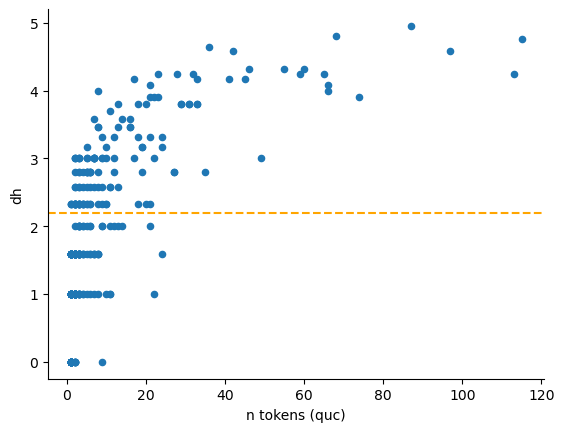

In [404]:
ax = TEMA.plot.scatter('quc', 'dh')
ax.axhline(2.2, ls='--', c='orange')
sns.despine()
plt.xlabel("n tokens (quc)")
plt.show()

## TEMAS over Time

In [405]:
min_dh = 3 # 1.06
IDX = TEMA.loc[TEMA.dh > min_dh].index
X = TEMA_TOKEN_QUC[TEMA_TOKEN_QUC.ana_id.isin(IDX)]
h = len(IDX) // 4


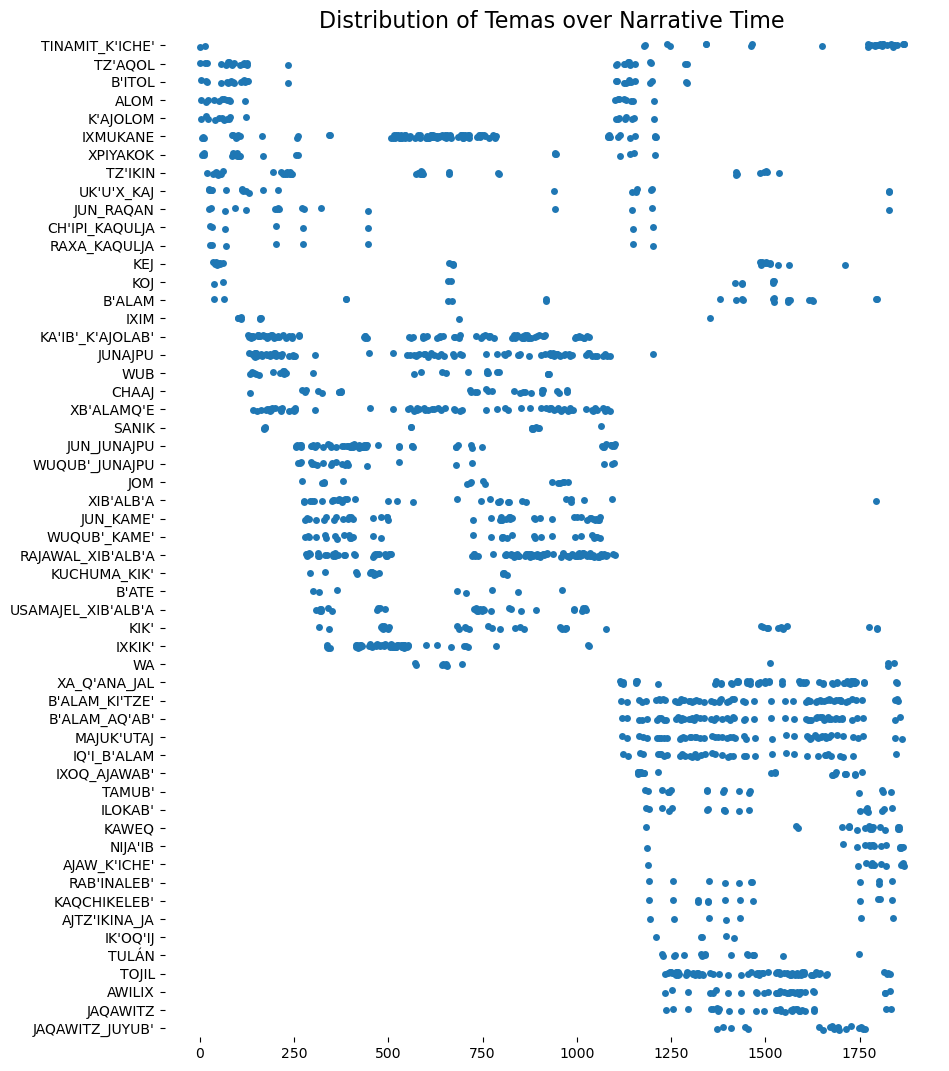

In [406]:
fig, ax = plt.subplots(figsize=(10, h))
sns.stripplot(x=X.reset_index().index, y=X.ana_id, ax=ax)
plt.xlabel("")
plt.ylabel("")
plt.title("Distribution of Temas over Narrative Time", fontsize=16, y=1)
plt.savefig("xom-temas-over-time.png")
plt.savefig("xom-temas-over-time.svg")
sns.despine(left=True, bottom=True)
plt.show()

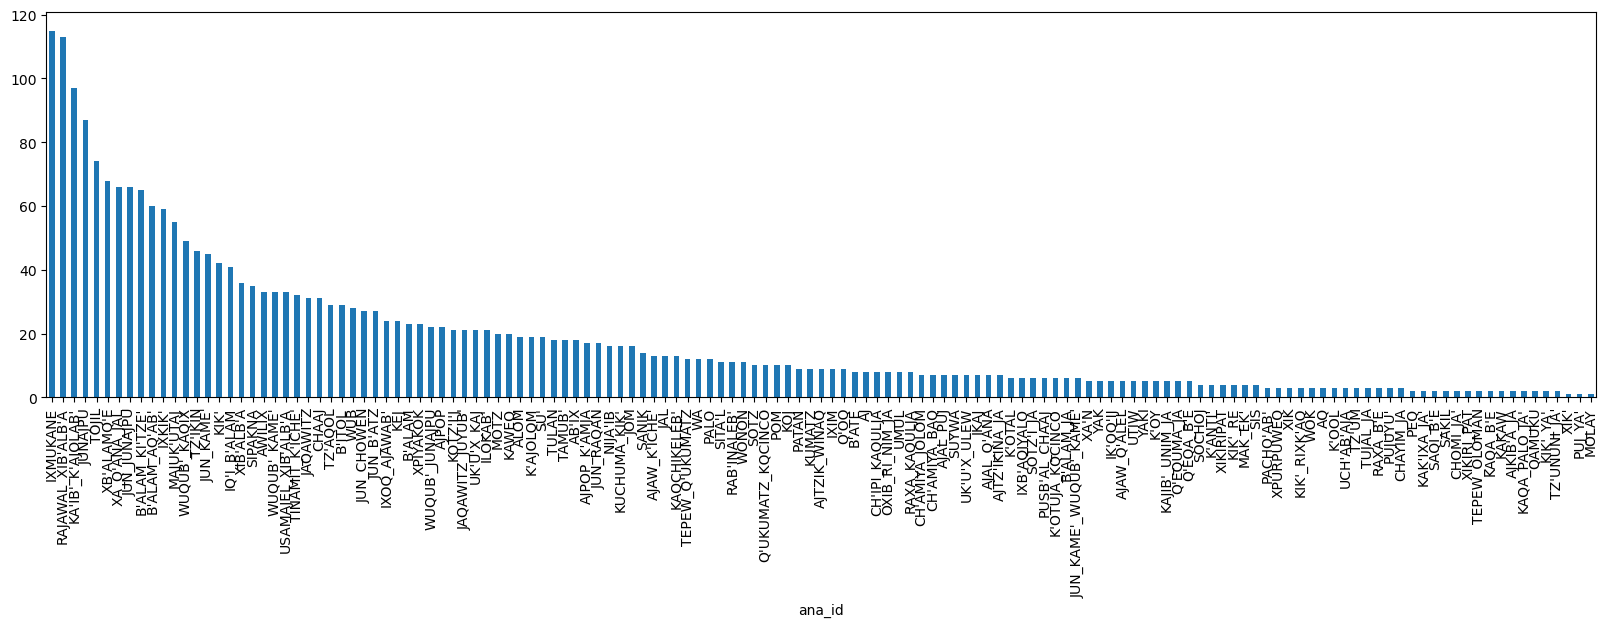

In [407]:
TEMA[TEMA.dh > 2].quc.sort_values(ascending=False).plot.bar(figsize=(20,5))
plt.show()